# make_rvr:
## Make river source conditions
### Version id:
### v2.1 estimates from Gladstone GlaDS for WAOM10 grid

In [1]:
cd /g/data/jk72/deg581/waom/ana/notebooks/

/g/data/jk72/deg581/waom/ana/notebooks


In [2]:
run = 'waom10'
suffix_name='_v1.0'

import xarray as xr
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec



grdfile_name = '../data/proc/waom10extend_grd.nc'

#######################################################

grd_file = os.path.join(grdfile_name)
grd = xr.open_dataset(grd_file)

grd.x_rho / grd.y_rho not found. Converting lon/lat to EPSG:3031 coordinates.
Domain filter removed 0 of 500 rivers
there are now  500  rivers


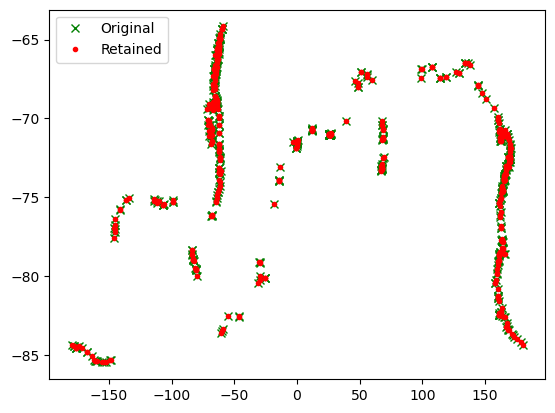

In [9]:
# ============================================================
# ROMS river source W-face forcing
# ============================================================

river_file = '../data/raw/GlaDS_AA_V1_0_gl_outflow.txt'

df = pd.read_csv(river_file, comment="#", delim_whitespace=True, header=None)
df.columns = ["gl_flux","gl_flux_scaled","x","y","lat","lon"]
    
def inpolygon(xq, yq, xv, yv):
    from matplotlib import path
    shape = xq.shape
    xq = xq.reshape(-1)
    yq = yq.reshape(-1)
    xv = xv.reshape(-1)
    yv = yv.reshape(-1)
    q = [(xq[i], yq[i]) for i in range(xq.shape[0])]
    p = path.Path([(xv[i], yv[i]) for i in range(xv.shape[0])])
    return p.contains_points(q).reshape(shape)

# --------------------------------------------------------
# PRE-FILTER RIVERS TO THOSE INSIDE MODEL DOMAIN
# --------------------------------------------------------

coord_system = "stereographic"   # "geographic" or "stereographic"

if coord_system == "geographic":

    poly_x = np.concatenate([
        grd.lon_rho[0, :],
        grd.lon_rho[:, -1],
        grd.lon_rho[-1, ::-1],
        grd.lon_rho[::-1, 0]
    ])

    poly_y = np.concatenate([
        grd.lat_rho[0, :],
        grd.lat_rho[:, -1],
        grd.lat_rho[-1, ::-1],
        grd.lat_rho[::-1, 0]
    ])

    xq = df["lon"].to_numpy()
    yq = df["lat"].to_numpy()

elif coord_system == "stereographic":

    # Use existing x/y coordinates if available
    if hasattr(grd, "x_rho") and hasattr(grd, "y_rho"):

        x_rho = grd.x_rho
        y_rho = grd.y_rho

    else:

        print("grd.x_rho / grd.y_rho not found. Converting lon/lat to EPSG:3031 coordinates.")

        from pyproj import Transformer

        transformer = Transformer.from_crs(
            "EPSG:4326",
            "EPSG:3031",
            always_xy=True
        )

        x_rho, y_rho = transformer.transform(
            grd.lon_rho.values,
            grd.lat_rho.values
        )

    poly_x = np.concatenate([
        x_rho[0, :],
        x_rho[:, -1],
        x_rho[-1, ::-1],
        x_rho[::-1, 0]
    ])

    poly_y = np.concatenate([
        y_rho[0, :],
        y_rho[:, -1],
        y_rho[-1, ::-1],
        y_rho[::-1, 0]
    ])

    xq = df["x"].to_numpy()
    yq = df["y"].to_numpy()

else:
    raise ValueError(f"Unknown coord_system: {coord_system}")

mask_valid = inpolygon(xq, yq, poly_x, poly_y)

df_orig = df.copy()
df = df.loc[mask_valid].copy()

Nriver = len(df)
print(f"Domain filter removed {len(df_orig) - len(df)} of {len(df_orig)} rivers")
print('there are now ',str(Nriver),' rivers')

plt.figure()
plt.plot(df_orig["lon"], df_orig["lat"], "gx", label="Original")
plt.plot(df["lon"], df["lat"], "r.", label="Retained")

if coord_system == "geographic":
    plt.plot(poly_x, poly_y, "k-")

plt.legend()
    
    
######## Extract river locations and transport

river_lon = df["lon"].to_numpy()
river_lat = df["lat"].to_numpy()

constant_transport = df["gl_flux_scaled"].to_numpy()

In [10]:
from scipy.spatial import cKDTree

def find_nearest_rho_points(river_lon, river_lat, grd):
    """
    Find nearest wet (mask_rho==1) rho-grid points for river locations.

    Parameters
    ----------
    river_lon : array-like (Nriver,)
    river_lat : array-like (Nriver,)
    grd : xarray.Dataset
        Must contain:
        - lon_rho (eta, xi)
        - lat_rho (eta, xi)
        - mask_rho (eta, xi)

    Returns
    -------
    river_eta : np.ndarray (Nriver,)
    river_xi  : np.ndarray (Nriver,)
    """

    mask = grd.mask_rho.values == 1

    lon_ocean = grd.lon_rho.values[mask]
    lat_ocean = grd.lat_rho.values[mask]

    eta_ocean, xi_ocean = np.where(mask)

    tree = cKDTree(np.column_stack((lon_ocean, lat_ocean)))

    dist, idx = tree.query(np.column_stack((river_lon, river_lat)))

    river_eta = eta_ocean[idx]
    river_xi = xi_ocean[idx]

    return river_eta.astype(int), river_xi.astype(int)


def find_nearest_rho_points_bruteforce(river_lon, river_lat, grd):
    """
    Find nearest wet (mask_rho==1) rho-grid points using brute-force search.

    Parameters
    ----------
    river_lon : array-like (Nriver,)
    river_lat : array-like (Nriver,)
    grd : xarray.Dataset
        Must contain lon_rho, lat_rho, mask_rho

    Returns
    -------
    river_eta : np.ndarray (Nriver,)
    river_xi  : np.ndarray (Nriver,)
    """

    mask = grd.mask_rho.values == 1
    lon = grd.lon_rho.values
    lat = grd.lat_rho.values

    lon_ocean = lon[mask]
    lat_ocean = lat[mask]

    eta_ocean, xi_ocean = np.where(mask)

    river_lon = np.asarray(river_lon)
    river_lat = np.asarray(river_lat)

    river_eta = np.empty(len(river_lon), dtype=int)
    river_xi  = np.empty(len(river_lon), dtype=int)

    for n, (rlon, rlat) in enumerate(zip(river_lon, river_lat)):

        dist2 = (lon_ocean - rlon)**2 + (lat_ocean - rlat)**2
        idx = np.argmin(dist2)

        river_eta[n] = eta_ocean[idx]
        river_xi[n]  = xi_ocean[idx]

    return river_eta, river_xi

In [11]:
# define functions to search for river outlet locations ALONG the grounding line

def get_gl_mask(mask_rho, connectivity=4, return_count=False):
    """
    Identify grounding-line ocean cells.

    A grounding-line cell is defined as an ocean cell (mask_rho==1)
    that has at least one neighbouring non-ocean cell.

    Parameters
    ----------
    mask_rho : xarray.DataArray
        ROMS mask (1=ocean, 0=land/grounded ice)

    connectivity : {4, 8}, optional
        Neighbour stencil:
            4 -> N,S,E,W
            8 -> N,S,E,W + diagonals

    return_count : bool, optional
        Return neighbour-count array as well.

    Returns
    -------
    gl_mask : xarray.DataArray (bool)

    count : xarray.DataArray (optional)
        Count = self + ocean neighbours.
    """

    ocean = (mask_rho == 1).astype(int)

    count = (
          ocean
        + ocean.shift(eta_rho= 1, fill_value=0)
        + ocean.shift(eta_rho=-1, fill_value=0)
        + ocean.shift(xi_rho= 1, fill_value=0)
        + ocean.shift(xi_rho=-1, fill_value=0)
    )

    if connectivity == 8:
        count = (
              count
            + ocean.shift(eta_rho= 1, xi_rho= 1, fill_value=0)
            + ocean.shift(eta_rho= 1, xi_rho=-1, fill_value=0)
            + ocean.shift(eta_rho=-1, xi_rho= 1, fill_value=0)
            + ocean.shift(eta_rho=-1, xi_rho=-1, fill_value=0)
        )
        max_count = 9

    elif connectivity == 4:
        max_count = 5
    else:
        raise ValueError("connectivity must be 4 or 8")

    gl_mask = (ocean == 1) & (count < max_count)
    if return_count:
        return gl_mask, count
    return gl_mask

def find_nearest_gl_rho_points(river_lon,river_lat,grd,connectivity=4,return_debug=False):
    """
    Find nearest grounding-line (GL) rho-grid points for river locations.

    A GL point is defined using get_gl_mask():
        ocean cells (mask_rho==1) that touch land/grounded ice.

    Parameters
    ----------
    river_lon : array-like (Nriver,)
    river_lat : array-like (Nriver,)
    grd : xarray.Dataset
        Must contain:
        - lon_rho (eta, xi)
        - lat_rho (eta, xi)
        - mask_rho (eta, xi)

    connectivity : {4, 8}
        Neighbour definition for GL detection.

    return_debug : bool
        If True, also return GL mask used.

    Returns
    -------
    river_eta : np.ndarray (Nriver,)
    river_xi  : np.ndarray (Nriver,)
    (optional) gl_mask : np.ndarray (eta, xi)
    """

    # --------------------------------------------------------
    # 1. Build grounding-line mask
    # --------------------------------------------------------
    gl_mask_da = get_gl_mask(grd.mask_rho, connectivity=connectivity)
    gl_mask = gl_mask_da.values.astype(bool)

    if not np.any(gl_mask):
        raise ValueError("No grounding-line cells found. Check mask_rho or connectivity.")

    # --------------------------------------------------------
    # 2. Extract GL coordinates
    # --------------------------------------------------------
    lon_gl = grd.lon_rho.values[gl_mask]
    lat_gl = grd.lat_rho.values[gl_mask]

    eta_gl, xi_gl = np.where(gl_mask)

    # --------------------------------------------------------
    # 3. Build KDTree in GL space only
    # --------------------------------------------------------
    tree = cKDTree(np.column_stack((lon_gl, lat_gl)))

    river_lon = np.asarray(river_lon)
    river_lat = np.asarray(river_lat)

    dist, idx = tree.query(np.column_stack((river_lon, river_lat)))

    river_eta = eta_gl[idx]
    river_xi  = xi_gl[idx]

    if return_debug:
        return river_eta.astype(int), river_xi.astype(int), dist, gl_mask

    return river_eta.astype(int), river_xi.astype(int), dist

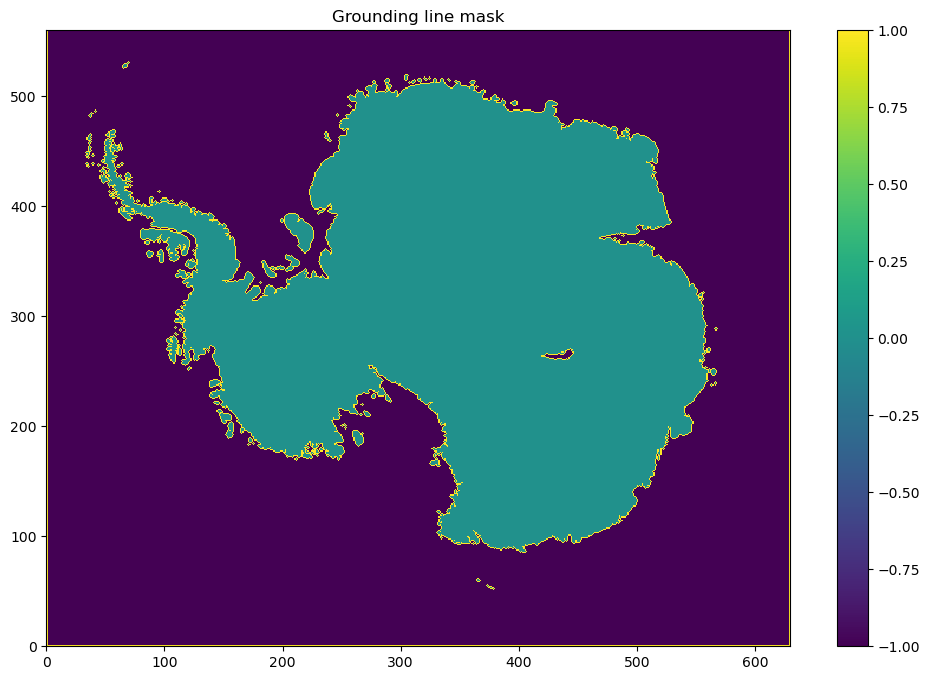

In [12]:
gl_mask = get_gl_mask(grd.mask_rho).values

plt.figure(figsize=(12,8))
plt.pcolormesh(gl_mask*2-grd.mask_rho)
plt.colorbar()
plt.title("Grounding line mask")
plt.show()

In [13]:

# ------------------------------------------------------------
# GRID LOOKUP
# ------------------------------------------------------------

# river_eta,river_xi = find_nearest_rho_points(river_lon,river_lat,grd) # find the closest point on the ocean mask - note might location into a non-border ocean cell if lat/lon is not over ice
# river_eta,river_xi = find_nearest_rho_points_bruteforce(river_lon, river_lat, grd) # as above, but different scheme
river_eta, river_xi, gl_dist = find_nearest_gl_rho_points(river_lon,river_lat,grd,connectivity=4)
bad = gl_dist > 5#np.percentile(gl_dist, 95)


print("Number of large-misfit points:", bad.sum())



Number of large-misfit points: 0


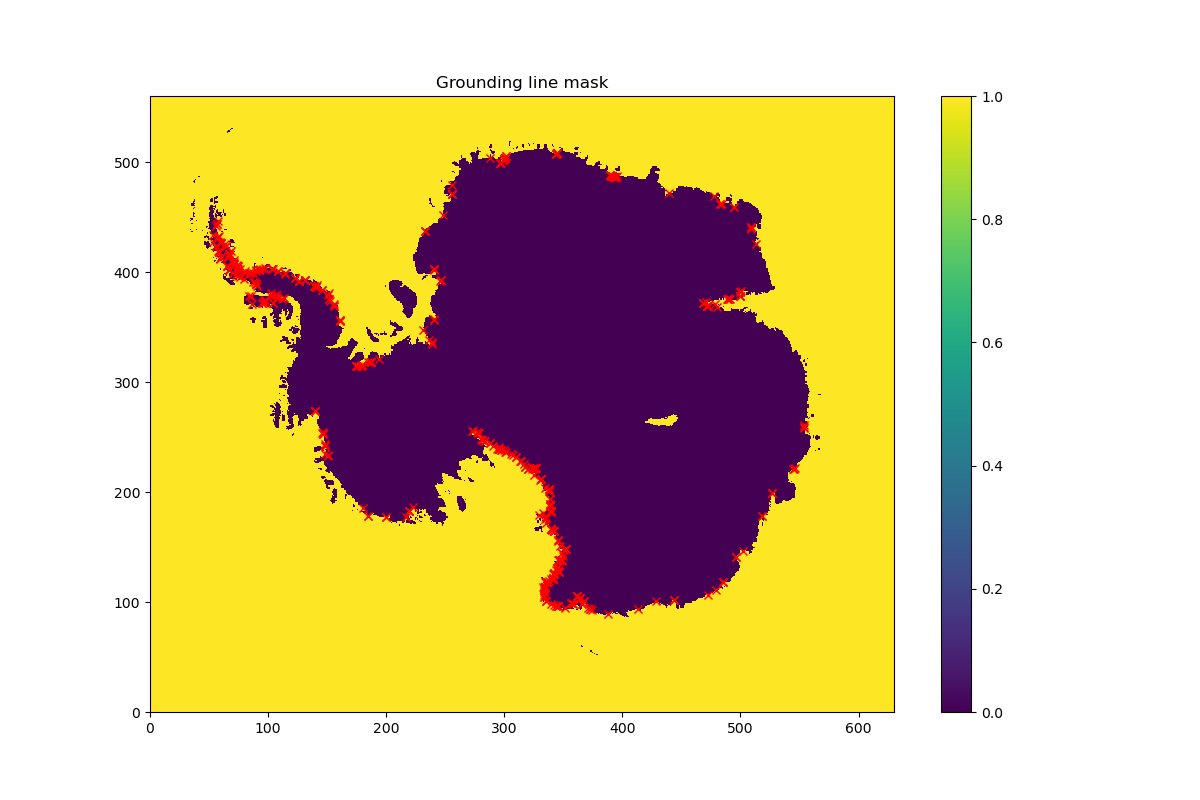

In [14]:
%matplotlib widget
plt.figure(figsize=(12,8))
plt.pcolormesh(grd.mask_rho)
plt.plot(river_xi+0.5,river_eta+.5,'rx')
plt.colorbar()
# plt.contour(gl_mask,levels=[0,1],colors='k',linewidths=1)
plt.title("Grounding line mask")
# plt.colorbar()
plt.show()

In [75]:
%matplotlib inline
plt.close('all')

/jobfs/173868859.gadi-pbs/ipykernel_3547932/1500972231.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pc = ax.pcolormesh(grd.lon_rho, grd.lat_rho, grd.h, cmap=cm.deep, shading="auto")


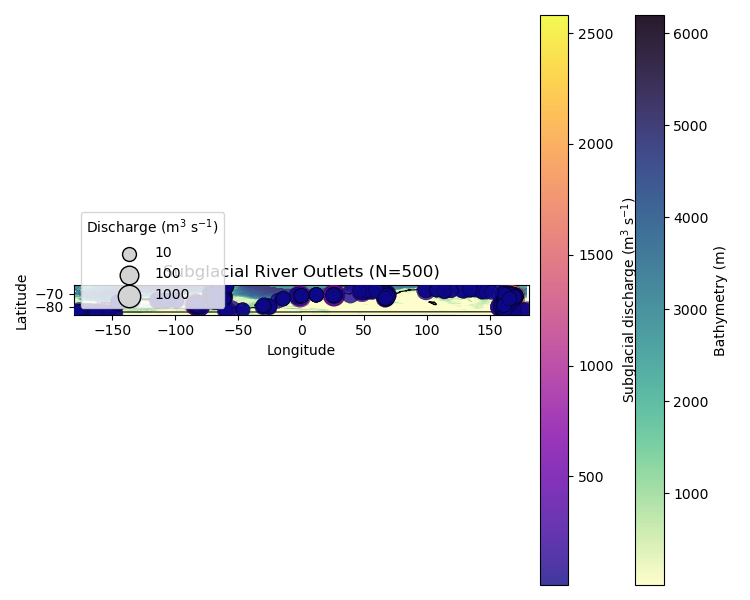

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from cmocean import cm

fig, ax = plt.subplots(figsize=(7.5,6))

pc = ax.pcolormesh(grd.lon_rho, grd.lat_rho, grd.h, cmap=cm.deep, shading="auto")

cbar = plt.colorbar(pc, ax=ax, pad=0.02)
cbar.set_label("Bathymetry (m)")

ax.contour(grd.lon_rho, grd.lat_rho, grd.mask_rho, levels=[0.5], colors="k", linewidths=0.8)

Q = df["gl_flux_scaled"].to_numpy()

sizes = 20 + 80*np.log10(Q)

sc = ax.scatter(df["lon"], df["lat"], s=sizes, c=Q, cmap="plasma", edgecolor="k", linewidth=0.25, alpha=0.8, zorder=5)

cbar2 = plt.colorbar(sc, ax=ax, pad=0.02)

cbar2.set_label("Subglacial discharge (m$^3$ s$^{-1}$)")

legend_flows = np.array([10, 100, 1000])

legend_sizes = 20 + 80*np.log10(legend_flows)

handles = [plt.scatter([], [], s=s, facecolor="lightgrey", edgecolor="k") for s in legend_sizes]

labels = [f"{q:g}" for q in legend_flows]

ax.legend(handles, labels, title="Discharge (m$^3$ s$^{-1}$)", loc="lower left", frameon=True)

pad = 1.0

ax.set_xlim(df["lon"].min() - pad, df["lon"].max() + pad)

ax.set_ylim(df["lat"].min() - pad, df["lat"].max() + pad)

ax.set_xlabel("Longitude")

ax.set_ylabel("Latitude")

ax.set_aspect("equal")

ax.set_title(f"Subglacial River Outlets (N={len(df)})")

plt.tight_layout()

/jobfs/173868859.gadi-pbs/ipykernel_3547932/4260528610.py:12: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pc = ax.pcolormesh(x_rho, y_rho, grd.h, cmap=cm.deep, shading="auto")
/jobfs/173868859.gadi-pbs/ipykernel_3547932/4260528610.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


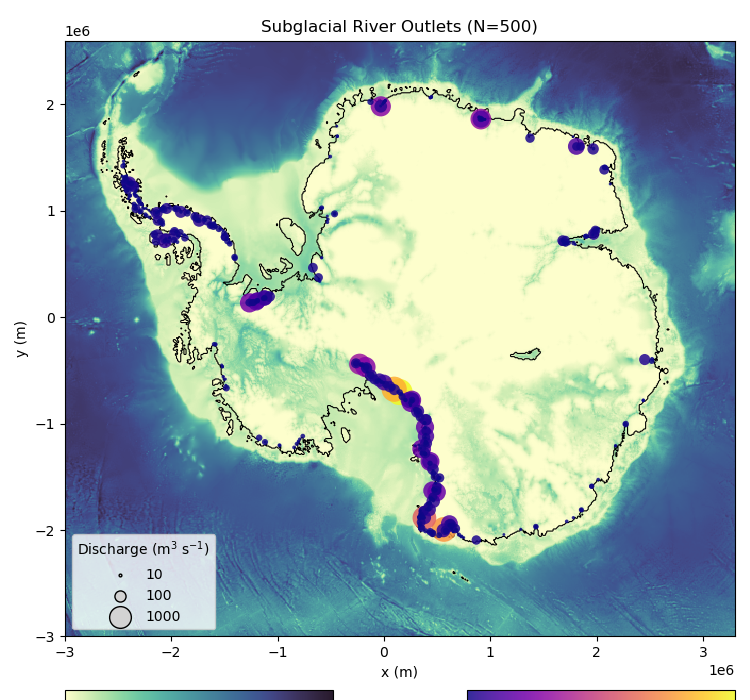

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from cmocean import cm

fig, ax = plt.subplots(figsize=(7.5, 7))

# --------------------------------------------------
# BACKGROUND
# --------------------------------------------------

pc = ax.pcolormesh(x_rho, y_rho, grd.h, cmap=cm.deep, shading="auto")

ax.contour(x_rho, y_rho, grd.mask_rho, levels=[0.5], colors="k", linewidths=0.8)

# --------------------------------------------------
# RIVERS
# --------------------------------------------------

Q = df["gl_flux_scaled"].to_numpy().astype(float)

Qlog = np.log10(Q)
Qnorm = (Qlog - np.log10(10)) / (np.log10(Q.max()) - np.log10(10) + 1e-12)
Qnorm = np.clip(Qnorm, 0, 1)

sizes = 4 + 350 * Qnorm**2

sc = ax.scatter(
    df["x"], df["y"],
    s=sizes,
    c=Q,
    cmap="plasma",
    edgecolor="none",
    alpha=0.85,
    zorder=5
)

# --------------------------------------------------
# INSET COLORBARS (40% width, horizontal, below plot)
# --------------------------------------------------

cax1 = inset_axes(
    ax, width="40%", height="3%", loc="lower left",
    bbox_to_anchor=(0.0, -0.12, 1, 1),
    bbox_transform=ax.transAxes, borderpad=0
)

cb1 = plt.colorbar(pc, cax=cax1, orientation="horizontal")
cb1.set_label("Bathymetry (m)")

cax2 = inset_axes(
    ax, width="40%", height="3%", loc="lower right",
    bbox_to_anchor=(0.0, -0.12, 1, 1),
    bbox_transform=ax.transAxes, borderpad=0
)

cb2 = plt.colorbar(sc, cax=cax2, orientation="horizontal")
cb2.set_label("Subglacial discharge (m$^3$ s$^{-1}$)")

# --------------------------------------------------
# LEGEND (bubble size guide)
# --------------------------------------------------

legend_flows = np.array([10, 100, 1000])

Qlog_l = np.log10(legend_flows)
Qlog10 = np.log10(10)

Qnorm_l = (Qlog_l - Qlog10) / (np.log10(Q.max()) - Qlog10 + 1e-12)
Qnorm_l = np.clip(Qnorm_l, 0, 1)

legend_sizes = 4 + 350 * Qnorm_l**2

handles = [
    plt.scatter([], [], s=s, facecolor="lightgrey", edgecolor="k")
    for s in legend_sizes
]

labels = [f"{q:g}" for q in legend_flows]

ax.legend(
    handles,
    labels,
    title="Discharge (m$^3$ s$^{-1}$)",
    loc="lower left",
    frameon=True
)

# --------------------------------------------------
# FORMATTING
# --------------------------------------------------

ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title(f"Subglacial River Outlets (N={len(df)})")

plt.tight_layout()